# Lemmatization

Lemmatization reduces words to their base or dictionary form (i.e., lemma)

In [1]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet') # https://www.nltk.org/api/nltk.corpus.reader.wordnet.html
nltk.download('punkt_tab')  # Завантажуємо токенізатор для word_tokenize

# Sample text
text = "Running wild cats run in the forest. They ran away when they saw a pack of wolves."

# Tokenize the text into words
words = nltk.word_tokenize(text)

# Initialize WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize each word
lemmatized_words = [lemmatizer.lemmatize(word) for word in words]

print("Original Words:", words)
print("Lemmatized Words:", lemmatized_words)

[nltk_data] Downloading package wordnet to /home/serhii/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/serhii/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Original Words: ['Running', 'wild', 'cats', 'run', 'in', 'the', 'forest', '.', 'They', 'ran', 'away', 'when', 'they', 'saw', 'a', 'pack', 'of', 'wolves', '.']
Lemmatized Words: ['Running', 'wild', 'cat', 'run', 'in', 'the', 'forest', '.', 'They', 'ran', 'away', 'when', 'they', 'saw', 'a', 'pack', 'of', 'wolf', '.']


# Stemming

Stemming is a text processing technique that reduces words to their base of root form, called a stem. Stemming removes suffixes and prefixes from words to achieve this normalization.

In [2]:
import nltk
from nltk.stem import SnowballStemmer

# Sample text
text = "Running wild cats run in the forest. They ran away when they saw a pack of wolves."

# Tokenize the text into words
words = nltk.word_tokenize(text)

# Initialize SnowballStemmer for English
stemmer = SnowballStemmer("english")

# Stem each word
stemmed_words = [stemmer.stem(word) for word in words]

print("Original Words:", words)
print("Stemmed Words:", stemmed_words)

Original Words: ['Running', 'wild', 'cats', 'run', 'in', 'the', 'forest', '.', 'They', 'ran', 'away', 'when', 'they', 'saw', 'a', 'pack', 'of', 'wolves', '.']
Stemmed Words: ['run', 'wild', 'cat', 'run', 'in', 'the', 'forest', '.', 'they', 'ran', 'away', 'when', 'they', 'saw', 'a', 'pack', 'of', 'wolv', '.']


# Tokenization

In [3]:
import nltk
from nltk.tokenize import word_tokenize, WordPunctTokenizer
from nltk.util import ngrams

# Sample text
text = "Tokenization is an important step in natural language processing."

# Character-level tokenization
char_tokens = list(text)
print("Character-level Tokens:", char_tokens)

# Word-level tokenization
word_tokens = word_tokenize(text)
print("Word-level Tokens:", word_tokens)

# N-gram level tokenization (bigrams)
n=2
n_grams = list(ngrams(word_tokenize(text), n))
print(f"{n}-grams:", n_grams)



Character-level Tokens: ['T', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n', ' ', 'i', 's', ' ', 'a', 'n', ' ', 'i', 'm', 'p', 'o', 'r', 't', 'a', 'n', 't', ' ', 's', 't', 'e', 'p', ' ', 'i', 'n', ' ', 'n', 'a', 't', 'u', 'r', 'a', 'l', ' ', 'l', 'a', 'n', 'g', 'u', 'a', 'g', 'e', ' ', 'p', 'r', 'o', 'c', 'e', 's', 's', 'i', 'n', 'g', '.']
Word-level Tokens: ['Tokenization', 'is', 'an', 'important', 'step', 'in', 'natural', 'language', 'processing', '.']
2-grams: [('Tokenization', 'is'), ('is', 'an'), ('an', 'important'), ('important', 'step'), ('step', 'in'), ('in', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', '.')]


In [4]:
# Trained tokenizer
# BPE ensures that the most common words are represented in the vocablulary as  a single token while the rare words are broken down
# into two or more tokens and this is in agreement with what a subword-based tokenization algorithm does.

from tokenizers import ByteLevelBPETokenizer

# Sample text
text = """Tokenization is an important step in natural language processing.
Tokenization is an important step in NLP.
Tokenization is an important process.
Process of tokenizing text sequences is important."""

# Initialize the ByteLevelBPETokenizer, used in GPT-2 and RoBERTa
# https://towardsdatascience.com/byte-pair-encoding-subword-based-tokenization-algorithm-77828a70bee0

tokenizer = ByteLevelBPETokenizer()

# Train the tokenizer on the sample text
tokenizer.train_from_iterator([text])

# Sub-word level tokenization (Byte-pair encoding)
subword_tokens = tokenizer.encode(text).tokens
print("Sub-word Tokens:", subword_tokens)




Sub-word Tokens: ['Tokenization', 'Ġis', 'Ġan', 'Ġimportant', 'Ġstep', 'Ġin', 'Ġ', 'n', 'at', 'u', 'r', 'a', 'l', 'Ġ', 'l', 'an', 'g', 'u', 'a', 'g', 'e', 'Ġprocess', 'ing', '.', 'Ċ', 'Tokenization', 'Ġis', 'Ġan', 'Ġimportant', 'Ġstep', 'Ġin', 'Ġ', 'N', 'L', 'P', '.', 'Ċ', 'Tokenization', 'Ġis', 'Ġan', 'Ġimportant', 'Ġprocess', '.', 'Ċ', 'P', 'rocess', 'Ġ', 'o', 'f', 'Ġ', 't', 'okeniz', 'ing', 'Ġ', 'te', 'x', 't', 'Ġs', 'e', 'q', 'u', 'en', 'ces', 'Ġis', 'Ġimportant', '.']


In [5]:
len(tokenizer.get_vocab())

292

In [6]:
tokenizer.get_vocab()

{'²': 110,
 'Ē': 206,
 '¸': 116,
 'ę': 213,
 'b': 65,
 'Ĥ': 224,
 'Â': 126,
 '£': 96,
 'F': 37,
 'Ġin': 288,
 '©': 102,
 'N': 45,
 'at': 259,
 'ģ': 223,
 '@': 31,
 'okeniz': 271,
 'Ì': 136,
 '¢': 95,
 'u': 84,
 'Å': 129,
 'f': 69,
 'Ń': 255,
 '"': 1,
 '^': 61,
 'ø': 180,
 'ù': 181,
 'Ě': 214,
 'Ð': 140,
 'Tokeniz': 274,
 '«': 104,
 'Ý': 153,
 'ces': 269,
 'Č': 200,
 'ļ': 248,
 'in': 285,
 'đ': 205,
 'Ö': 146,
 '{': 90,
 'ä': 160,
 'l': 75,
 'r': 81,
 'Ĭ': 232,
 'or': 264,
 'ë': 167,
 '+': 10,
 'Ķ': 242,
 'à': 156,
 'S': 50,
 '8': 23,
 '3': 18,
 'ė': 211,
 'í': 169,
 'Tokenization': 284,
 'ò': 174,
 'ĸ': 244,
 'm': 76,
 'ã': 159,
 '.': 13,
 '»': 119,
 '7': 22,
 'Ĳ': 238,
 'ġ': 221,
 'Ù': 149,
 '×': 147,
 'Ĩ': 228,
 'v': 85,
 'B': 33,
 'č': 201,
 '¹': 117,
 'O': 46,
 'c': 66,
 'Đ': 204,
 'ce': 260,
 'w': 86,
 'ĉ': 197,
 'Ú': 150,
 'D': 35,
 'Ô': 144,
 'oken': 265,
 'Ġan': 280,
 'atio': 281,
 'ě': 215,
 'L': 43,
 'ó': 175,
 'Ġi': 256,
 'ď': 203,
 'k': 74,
 'h': 71,
 'È': 132,
 'y': 88,
 '

In [7]:
tokenizer.id_to_token(1)

'"'

Training your own tokenizer: https://huggingface.co/learn/nlp-course/en/chapter6/8

In [8]:
# Training from scratch
## WordPiece Tokenizer: Training your own tokenizer: https://huggingface.co/learn/nlp-course/en/chapter6/6

from tokenizers import (
    decoders,
    models,
    normalizers,
    pre_tokenizers,
    processors,
    trainers,
    Tokenizer,
)

from tokenizers.pre_tokenizers import Whitespace

tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))

tokenizer.normalizer = normalizers.Sequence(
    [normalizers.NFD(), normalizers.Lowercase(), normalizers.StripAccents()]
)

print(tokenizer.normalizer.normalize_str("Héllò hôw are ü?"))


hello how are u?


In [9]:
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
tokenizer.pre_tokenizer.pre_tokenize_str("Let's test my pre-tokenizer.")

[('Let', (0, 3)),
 ("'", (3, 4)),
 ('s', (4, 5)),
 ('test', (6, 10)),
 ('my', (11, 13)),
 ('pre', (14, 17)),
 ('-', (17, 18)),
 ('tokenizer', (18, 27)),
 ('.', (27, 28))]

In [10]:
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "The cat sits on the window sill",
    "The dog barks loudly in the night",
    "Birds of a feather flock together",
    "Tokenization is an important step in natural language processing.",
    "Tokenization is an important step in NLP.",
    "Tokenization is an important process.",
    "Process of tokenizing text sequences is important."
]

special_tokens = ["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]
trainer = trainers.WordPieceTrainer(vocab_size=1000, special_tokens=special_tokens)
tokenizer.train_from_iterator(corpus, trainer=trainer)
tokenizer.decoder = decoders.WordPiece(prefix="##")
tokenizer.save("./tokenizer-trained.json")
#tokenizer = Tokenizer.from_file("./tokenizer-trained.json")

In [11]:
encoding = tokenizer.encode("The quick brown fox")
print("Tokens:", encoding.tokens)
print("Token IDs:", encoding.ids)

Tokens: ['the', 'quick', 'brown', 'fox']
Token IDs: [57, 172, 147, 150]


In [12]:
tokenizer.get_vocab()

{'fe': 103,
 'to': 59,
 'cat': 101,
 '##k': 39,
 '##in': 80,
 '##mps': 140,
 'win': 117,
 'step': 97,
 '##y': 53,
 'quick': 172,
 'window': 164,
 'proces': 85,
 '[SEP]': 3,
 'sits': 144,
 '##v': 55,
 'natural': 171,
 '[MASK]': 4,
 'barks': 166,
 'birds': 167,
 '##ra': 118,
 'y': 30,
 'o': 20,
 '##n': 38,
 'te': 116,
 '##dow': 137,
 'w': 28,
 '[CLS]': 2,
 '##an': 61,
 'impor': 72,
 'sequences': 173,
 'k': 16,
 'in': 77,
 '##ther': 122,
 'ba': 99,
 '##tan': 67,
 '##tant': 73,
 '##l': 45,
 'lan': 108,
 'br': 98,
 '##w': 51,
 '##d': 52,
 '##x': 46,
 'lo': 106,
 '##at': 58,
 '##quen': 136,
 'lazy': 155,
 'langu': 156,
 'loudly': 168,
 'e': 10,
 '##en': 62,
 'bark': 148,
 '##he': 56,
 '##own': 146,
 '##ll': 129,
 '##mp': 60,
 '##on': 79,
 '##ge': 93,
 'nl': 110,
 'dog': 96,
 'la': 107,
 '##e': 40,
 'important': 75,
 '##uen': 134,
 'b': 7,
 'quic': 161,
 'v': 27,
 'together': 165,
 'f': 11,
 '##g': 43,
 'over': 160,
 'nlp': 158,
 'jumps': 153,
 '##u': 49,
 'ni': 109,
 '##ow': 91,
 'an': 76,
 

In [13]:
tokenizer.decode(encoding.ids)

'the quick brown fox'

In [14]:
tokenizer.get_vocab_size()

174

# Text Embeddings

https://www.deepset.ai/blog/the-beginners-guide-to-text-embeddings

## Sparse (розрідженні) vectors: ONe hot encoding, Bag of words, Tf-idf

In [15]:
from nltk.tokenize import word_tokenize
import numpy as np
import nltk

# Sample text
text = "The quick brown fox jumps over the lazy dog"

# Tokenize the text into words
tokens = word_tokenize(text.lower())
print("Tokens:", tokens)
# Create vocabulary
vocab = sorted(set(tokens))
print("Vocabulary:", vocab)


Tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
Vocabulary: ['brown', 'dog', 'fox', 'jumps', 'lazy', 'over', 'quick', 'the']


In [16]:
# Create one-hot encoding
one_hot_encoded = []
for token in tokens:
    one_hot_vector = np.zeros(len(vocab), dtype=int) # or [0] * len(vocab)
    index = vocab.index(token)
    one_hot_vector[index] = 1 # Or one_hot_vector[vocab.index(token)] = 1
    one_hot_encoded.append(one_hot_vector)
one_hot_encoded

[array([0, 0, 0, 0, 0, 0, 0, 1]),
 array([0, 0, 0, 0, 0, 0, 1, 0]),
 array([1, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 1, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 1, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 1, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 1]),
 array([0, 0, 0, 0, 1, 0, 0, 0]),
 array([0, 1, 0, 0, 0, 0, 0, 0])]

In [ ]:
# Convet to numpy array for better manipulation
one_hot_encoded = np.array(one_hot_encoded)

# Print results
print("Original Text:", text)
print("Tokens:", tokens)
print("Vocabulary:", vocab) # word 'the'  is the last one in the list and that's why in one_hot_encoded last element is `1` for the word 'the'
print("One-hot Encoded Matrix:\n", one_hot_encoded)

Original Text: The quick brown fox jumps over the lazy dog
Tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
Vocabulary: ['brown', 'dog', 'fox', 'jumps', 'lazy', 'over', 'quick', 'the']
One-hot Encoded Matrix:
 [[0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]]


In [18]:
# Bag of words (BoW) representation

# Initialize Bag of Words
bow = np.zeros(len(vocab), dtype=int)

# Count the occurrences of each token in the text
for token in tokens:
    index = vocab.index(token)
    bow[index] += 1

# Print results
print("Original Text:", text)
print("Tokens:", tokens)
print("Vocabulary:", vocab)
print("Bag of Words Vector:", bow)

# And just like that, we have managed to encode our text as a vector
# (also known as a "bag of words" or "BoW" embedding - because it ignores the order of the words in the sentence)



Original Text: The quick brown fox jumps over the lazy dog
Tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
Vocabulary: ['brown', 'dog', 'fox', 'jumps', 'lazy', 'over', 'quick', 'the']
Bag of Words Vector: [1 1 1 1 1 1 1 2]


In [19]:
# TF-idf
# see module 7 lesson 1
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample corpus
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "The cat sits on the window sill",
    "The dog barks loudly in the night",
    "Birds of a feather flock together",
]

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Get feature names (vocabulary)
vocab = tfidf_vectorizer.get_feature_names_out()

# Convet TF-IDF matrix to dense array for easier manipulation
tfidf_matrix_dense = tfidf_matrix.toarray()

# Print results
print("Sample Corpus:", corpus)
print("Vocabulary:", vocab)
print("TF-IDF Matrix (Dense):", tfidf_matrix_dense)

Sample Corpus: ['The quick brown fox jumps over the lazy dog', 'The cat sits on the window sill', 'The dog barks loudly in the night', 'Birds of a feather flock together']
Vocabulary: ['barks' 'birds' 'brown' 'cat' 'dog' 'feather' 'flock' 'fox' 'in' 'jumps'
 'lazy' 'loudly' 'night' 'of' 'on' 'over' 'quick' 'sill' 'sits' 'the'
 'together' 'window']
TF-IDF Matrix (Dense): [[0.         0.         0.34812928 0.         0.27446912 0.
  0.         0.34812928 0.         0.34812928 0.34812928 0.
  0.         0.         0.         0.34812928 0.34812928 0.
  0.         0.44441281 0.         0.        ]
 [0.         0.         0.         0.38837832 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.38837832 0.         0.         0.38837832
  0.38837832 0.4957937  0.         0.38837832]
 [0.39996052 0.         0.         0.         0.31533346 0.
  0.         0.         0.39996052 0.         0.         0.39996052
  0.39996052 0.         0.         0.

# Cosine similarity
https://github.com/saqemlas/deep-learning-specialization/blob/main/5_SequenceModels/week_2/Assignment/Operations_on_word_vectors.ipynb

In [20]:
# Show vector similarity
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Sample vectors
vector1 = np.array([1, 2, 3])
vector2 = np.array([4, 5, 6])

# Reshape the vectors to ensure they are 2D (required for cosine_similarity)
vector1 = vector1.reshape(1, -1)
vector2 = vector2.reshape(1, -1)

# Calculate cosine similarity
similarity = cosine_similarity(vector1, vector2)
print("Vector 1:", vector1)
print("Vector 2:", vector2)
print("Cosine Similarity:", similarity[0][0])

Vector 1: [[1 2 3]]
Vector 2: [[4 5 6]]
Cosine Similarity: 0.9746318461970762


In [21]:
def cosine_similarity(u, v):
    """Cosine similarity reflects the degree of similarity between vect1 and vec2.
    
    Arguments:
    u = a word vector of shape (n,)
    v = a word vector of shape (n,)
    
    Returns:
    cosine_similarity - the cosine similarity between u and v defined by the formula above.
    """
    # Special case. Consider the case u = [0, 0], v = [0, 0]
    if np.all(u==v):
        return 1
    
    ### START CODE HERE ### (≈ 3 lines of code)
    # Compute the dot product between u and v. Use np.dot() or np.sum()
    dot = np.dot(u, v)
    # Compute the L2 norm of u and v. Use np.linalg.norm()
    norm_u = np.sqrt(np.sum(np.dot(u, u)))
    norm_v = np.sqrt(np.sum(np.dot(v, v)))

    # Avoid division by zero
    if np.isclose(norm_u*norm_v, 0, atol=1e-8):
        return 0
    
    # Compute the cosine similarity
    cosine_similarity = dot / (norm_u * norm_v)
    ### END CODE HERE ###

    return cosine_similarity

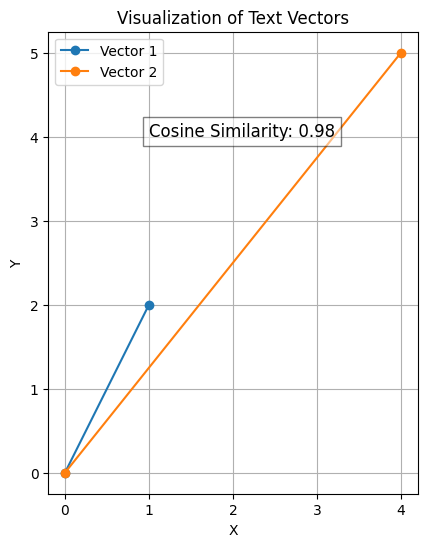

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Sample text vectors (e.g., TF-IDF vectors)
vector1 = np.array([1, 2])
vector2 = np.array([4, 5])

# Reshape vectors for cosine_similarity function (insure thy are 2D)
vector1 = vector1.reshape(1, -1)
vector2 = vector2.reshape(1, -1)

# Calculate cosine similarity
similarity = cosine_similarity(vector1, vector2)[0][0]

# Plotting the vectors
plt.figure(figsize=(8, 6))
plt.plot([0, vector1[0][0]], [0, vector1[0][1]], label='Vector 1', marker='o')
plt.plot([0, vector2[0][0]], [0, vector2[0][1]], label='Vector 2', marker='o')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Visualization of Text Vectors')
plt.legend()


# Annotate the cosine similarity
plt.text(1, 4, f'Cosine Similarity: {similarity:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Set aspect ratio to equal for better visualization
plt.gca().set_aspect('equal', adjustable='box')

# Show the plot
plt.grid()
plt.show()

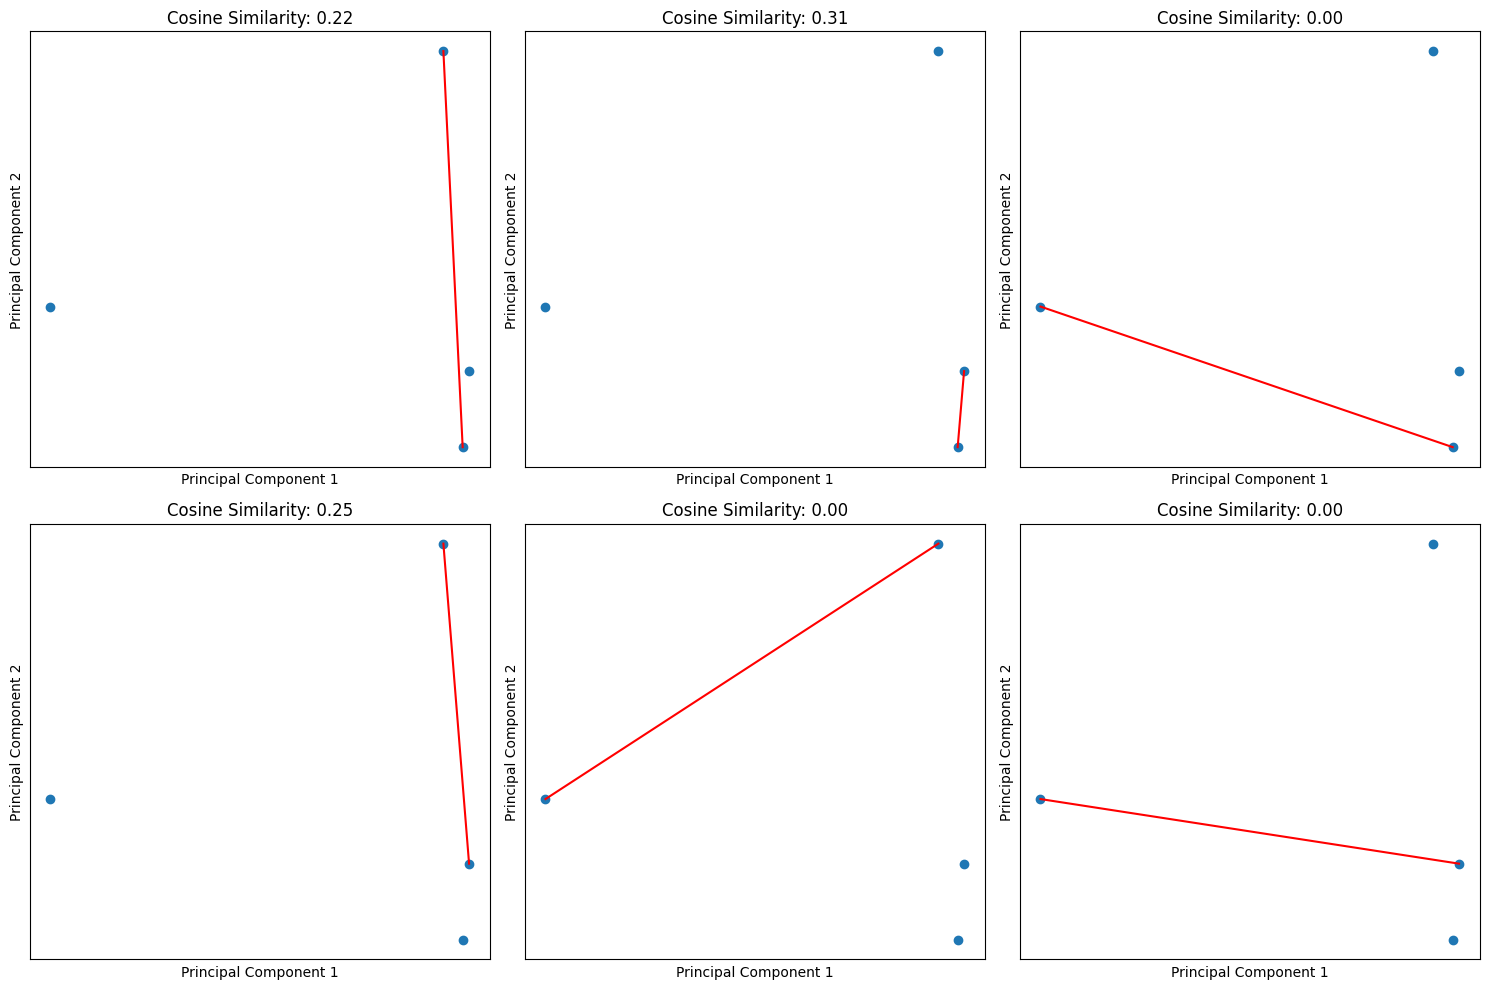

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Sample corpus
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "The cat sits on the window sill",
    "The dog barks loudly in the night",
    "Birds of a feather flock together",
]

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Convert TF-IDF matrix to dense array for PCA
tfidf_matrix_dense = tfidf_matrix.toarray()

# Compute cosine similarity matrix
cos_sim = cosine_similarity(tfidf_matrix_dense)

# Perform PCA to reduce dimensionality to 2D
pca = PCA(n_components=2)
tfidf_matrix_pca = pca.fit_transform(tfidf_matrix_dense)

# Plot one graph per pair of text
num_pairs = len(corpus) * (len(corpus) - 1) // 2
plt.figure(figsize=(15, 10))
subplot_index = 1
for i in range(len(corpus)):
    for j in range(i + 1, len(corpus)):
        plt.subplot(2, num_pairs//2, subplot_index)
        plt.scatter(tfidf_matrix_pca[:, 0], tfidf_matrix_pca[:, 1])
        plt.plot([tfidf_matrix_pca[i, 0], tfidf_matrix_pca[j, 0]],
                 [tfidf_matrix_pca[i, 1], tfidf_matrix_pca[j, 1]],
                 linestyle='-', color='red')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.title(f'Cosine Similarity: {cos_sim[i,j]:.2f}')
        plt.xticks([])
        plt.yticks([])
        subplot_index += 1
plt.tight_layout()
plt.show()

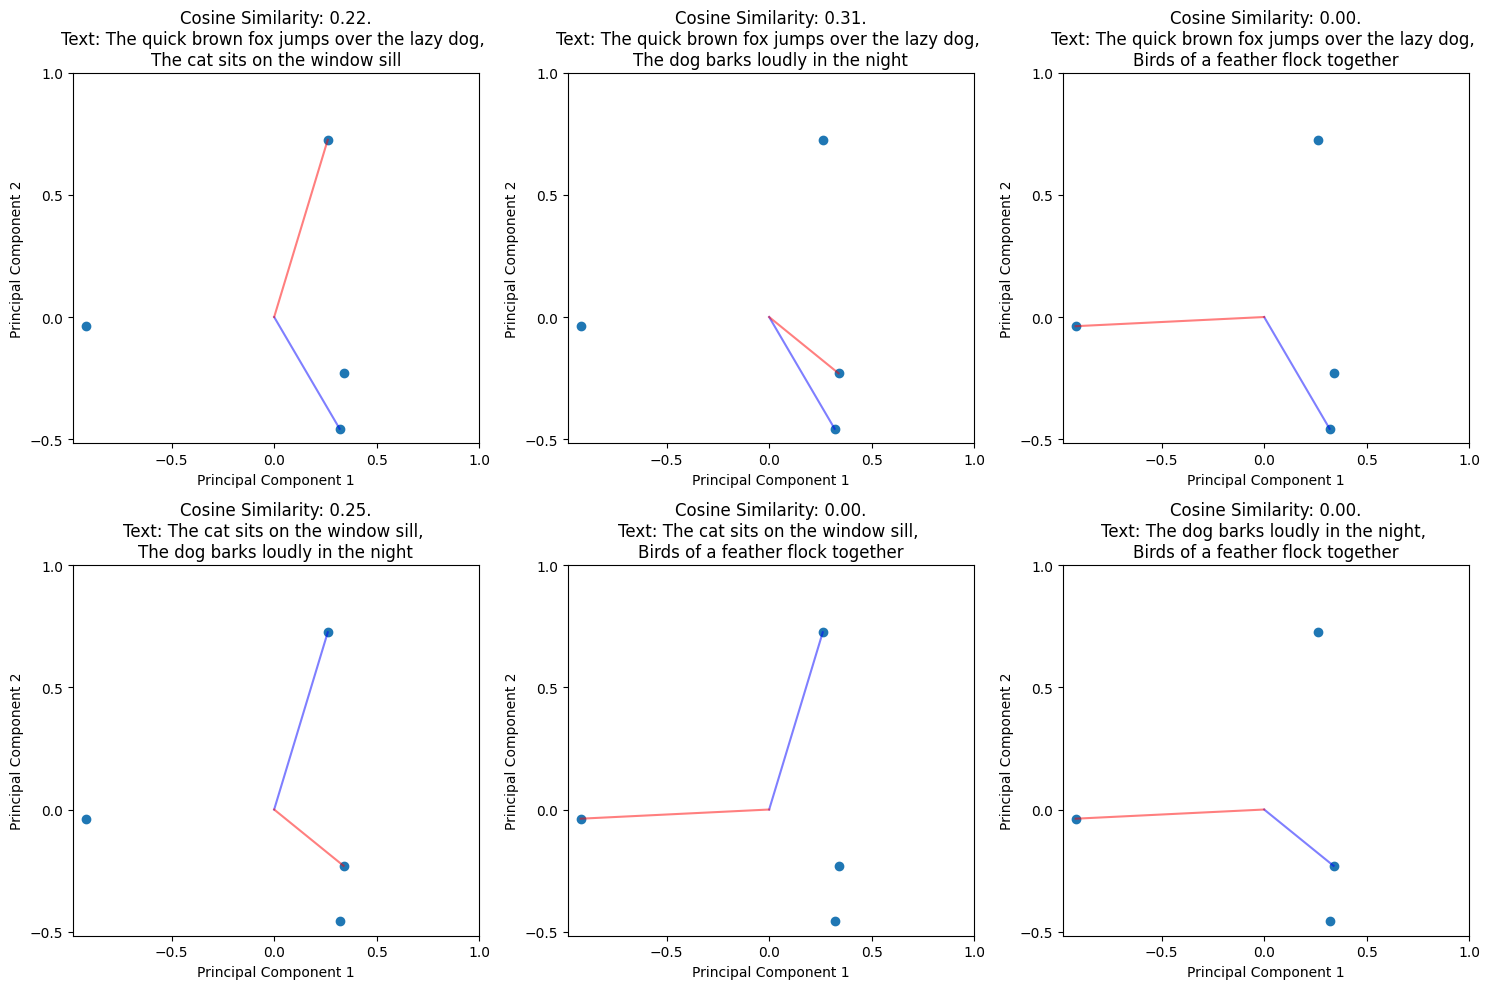

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Sample corpus
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "The cat sits on the window sill",
    "The dog barks loudly in the night",
    "Birds of a feather flock together",
]

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Convert TF-IDF matrix to dense array for PCA
tfidf_matrix_dense = tfidf_matrix.toarray()

# Compute cosine similarity matrix
cos_sim = cosine_similarity(tfidf_matrix_dense)

# Perform PCA to reduce dimensionality to 2D
pca = PCA(n_components=2)
tfidf_matrix_pca = pca.fit_transform(tfidf_matrix_dense)

# Plotting the reduced vectors
num_pairs = len(corpus) * (len(corpus) - 1) // 2
plt.figure(figsize=(15, 10))
subplot_index = 1
for i in range(len(corpus)):
    for j in range(i + 1, len(corpus)):
        plt.subplot(2, num_pairs//2, subplot_index)
        plt.scatter(tfidf_matrix_pca[:, 0], tfidf_matrix_pca[:, 1])
        plt.plot([ 0, tfidf_matrix_pca[i, 0]],
                 [0, tfidf_matrix_pca[i, 1]],
                 linestyle='-', color='blue', alpha=0.5)
        plt.plot([ 0, tfidf_matrix_pca[j, 0]],
                 [0, tfidf_matrix_pca[j, 1]],
                 linestyle='-', color='red', alpha=0.5)
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.title(f'Cosine Similarity: {cos_sim[i,j]:.2f}.\nText: {corpus[i]}, \n{corpus[j]}')

        plt.xticks(np.arange(-0.5, 1.5, 0.5))
        plt.yticks(np.arange(-0.5, 1.5, 0.5))
        subplot_index += 1
plt.tight_layout()
plt.show()  


# Word2Vec
https://www.tensorflow.org/text/tutorials/word2vec